In [2]:
# importing necessary libraries for data analysis and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE


In [3]:
#read dataset
df=pd.read_csv("/Users/ersilacka/Desktop/BBK Project 26/Datasets/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
"""
Framingham Heart Study Dataset - Column Descriptions

Demographic:
    sex         : 0 = Female, 1 = Male
    age         : Age at examination (32-81 years)
    education   : 1 = 0-11 years, 2 = High School, 3 = Some College, 4 = College Degree

Behavioral:
    currentSmoker : 0 = Not current smoker, 1 = Current smoker
    cigsPerDay    : Number of cigarettes per day (0-90)

Clinical:
    totChol   : Total cholesterol (mg/dL, 107-696)
    sysBP     : Systolic blood pressure (mmHg, 83.5-295)
    diaBP     : Diastolic blood pressure (mmHg, 30-150)
    BMI       : Body Mass Index (kg/m², 14.43-56.8)
    heartRate : Heart rate (beats/min, 37-220)
    glucose   : Casual serum glucose (mg/dL, 39-478)

Medical History:
    prevalentStroke : 0 = No prior stroke, 1 = Prior stroke
    prevalentHyp    : 0 = No hypertension, 1 = Hypertension
    diabetes        : 0 = No diabetes, 1 = Diabetes
    BPMeds          : 0 = No BP medication, 1 = BP medication

Outcome:
    TenYearCHD : 10-year coronary heart disease risk
                 0 = No event within 10 years
                 1 = Event within 10 years
"""

'\nFramingham Heart Study Dataset - Column Descriptions\n\nDemographic:\n    sex         : 0 = Female, 1 = Male\n    age         : Age at examination (32-81 years)\n    education   : 1 = 0-11 years, 2 = High School, 3 = Some College, 4 = College Degree\n\nBehavioral:\n    currentSmoker : 0 = Not current smoker, 1 = Current smoker\n    cigsPerDay    : Number of cigarettes per day (0-90)\n\nClinical:\n    totChol   : Total cholesterol (mg/dL, 107-696)\n    sysBP     : Systolic blood pressure (mmHg, 83.5-295)\n    diaBP     : Diastolic blood pressure (mmHg, 30-150)\n    BMI       : Body Mass Index (kg/m², 14.43-56.8)\n    heartRate : Heart rate (beats/min, 37-220)\n    glucose   : Casual serum glucose (mg/dL, 39-478)\n\nMedical History:\n    prevalentStroke : 0 = No prior stroke, 1 = Prior stroke\n    prevalentHyp    : 0 = No hypertension, 1 = Hypertension\n    diabetes        : 0 = No diabetes, 1 = Diabetes\n    BPMeds          : 0 = No BP medication, 1 = BP medication\n\nOutcome:\n    T

In [5]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
print(df.describe())

              male          age    education  currentSmoker   cigsPerDay  \
count  4240.000000  4240.000000  4135.000000    4240.000000  4211.000000   
mean      0.429245    49.580189     1.979444       0.494104     9.005937   
std       0.495027     8.572942     1.019791       0.500024    11.922462   
min       0.000000    32.000000     1.000000       0.000000     0.000000   
25%       0.000000    42.000000     1.000000       0.000000     0.000000   
50%       0.000000    49.000000     2.000000       0.000000     0.000000   
75%       1.000000    56.000000     3.000000       1.000000    20.000000   
max       1.000000    70.000000     4.000000       1.000000    70.000000   

            BPMeds  prevalentStroke  prevalentHyp     diabetes      totChol  \
count  4187.000000      4240.000000   4240.000000  4240.000000  4190.000000   
mean      0.029615         0.005896      0.310613     0.025708   236.699523   
std       0.169544         0.076569      0.462799     0.158280    44.591284   

In [7]:
# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [8]:

print("DATASET OVERVIEW")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows:\n{df.head()}")


DATASET OVERVIEW
Shape: 4240 rows, 16 columns

First 5 rows:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0   

In [9]:
# 2. CHECK DATA TYPES AND MISSING VALUES

print("DATA TYPES & MISSING VALUES")

print(df.dtypes)
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage missing: {(df.isnull().sum().sum() / df.size) * 100:.2f}%")

DATA TYPES & MISSING VALUES
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Missing values per column:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Total missing values: 645
Percentage missing: 0.95%


In [10]:

print("TARGET VARIABLE (TenYearCHD)")

print(df['TenYearCHD'].value_counts())
print(f"\nPercentage with CHD: {df['TenYearCHD'].mean() * 100:.2f}%")


TARGET VARIABLE (TenYearCHD)
TenYearCHD
0    3596
1     644
Name: count, dtype: int64

Percentage with CHD: 15.19%


In [11]:
#Imputing missing values

print("IMPUTING MISSING VALUES")

# Separate numerical and categorical columns
num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
cat_cols = ['male', 'currentSmoker', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'BPMeds', 'education']

# Impute numerical columns with median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute categorical columns with mode (most frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


IMPUTING MISSING VALUES


In [12]:
# Verify no missing values remain
print(f"\nMissing values after imputation:\n{df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0, "There are still missing values!"
print("✓ Verification passed: No missing values remain in the dataset")


Missing values after imputation:
0
✓ Verification passed: No missing values remain in the dataset


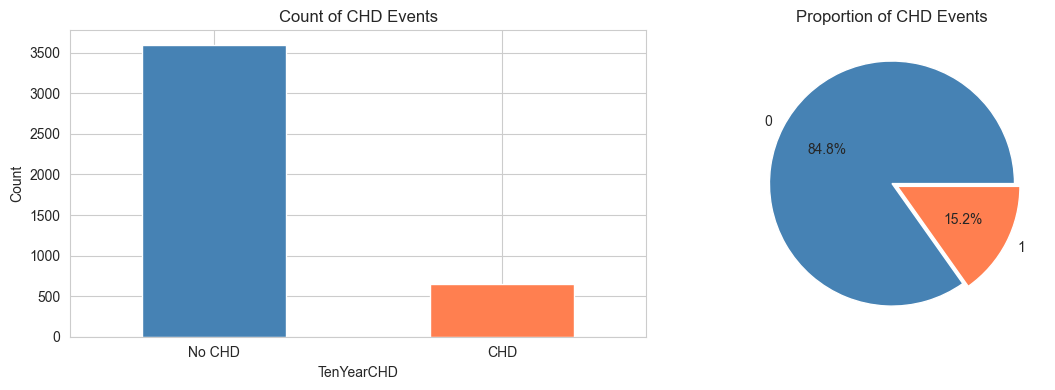

In [13]:
# Visualize target imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['TenYearCHD'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Count of CHD Events')
axes[0].set_xticklabels(['No CHD', 'CHD'], rotation=0)
axes[0].set_ylabel('Count')

df['TenYearCHD'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                                    colors=['steelblue', 'coral'], explode=(0, 0.05))
axes[1].set_title('Proportion of CHD Events')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

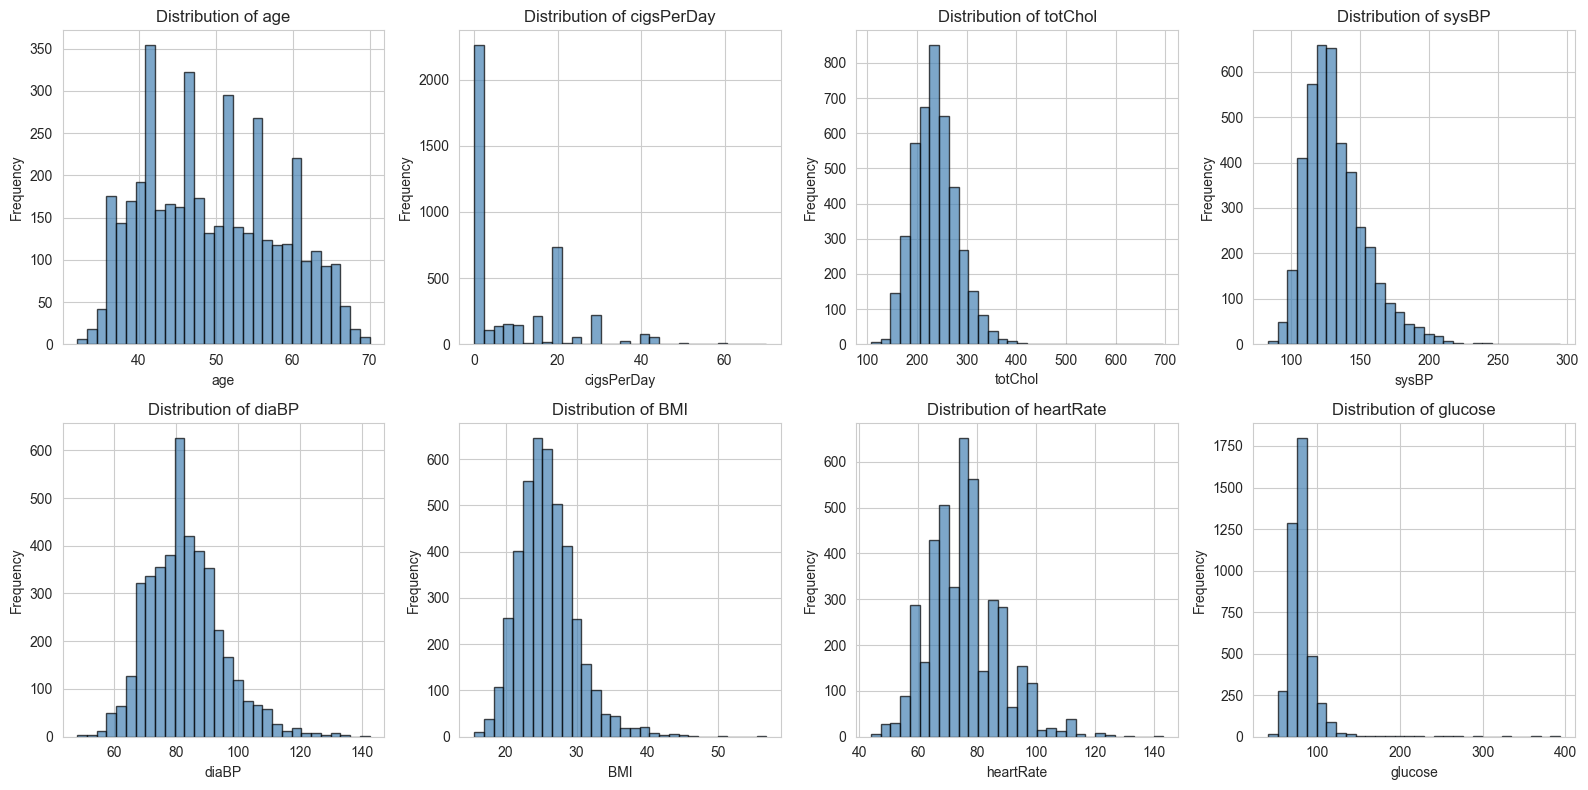

In [14]:
#distribution of numeric features

num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150)
plt.show()

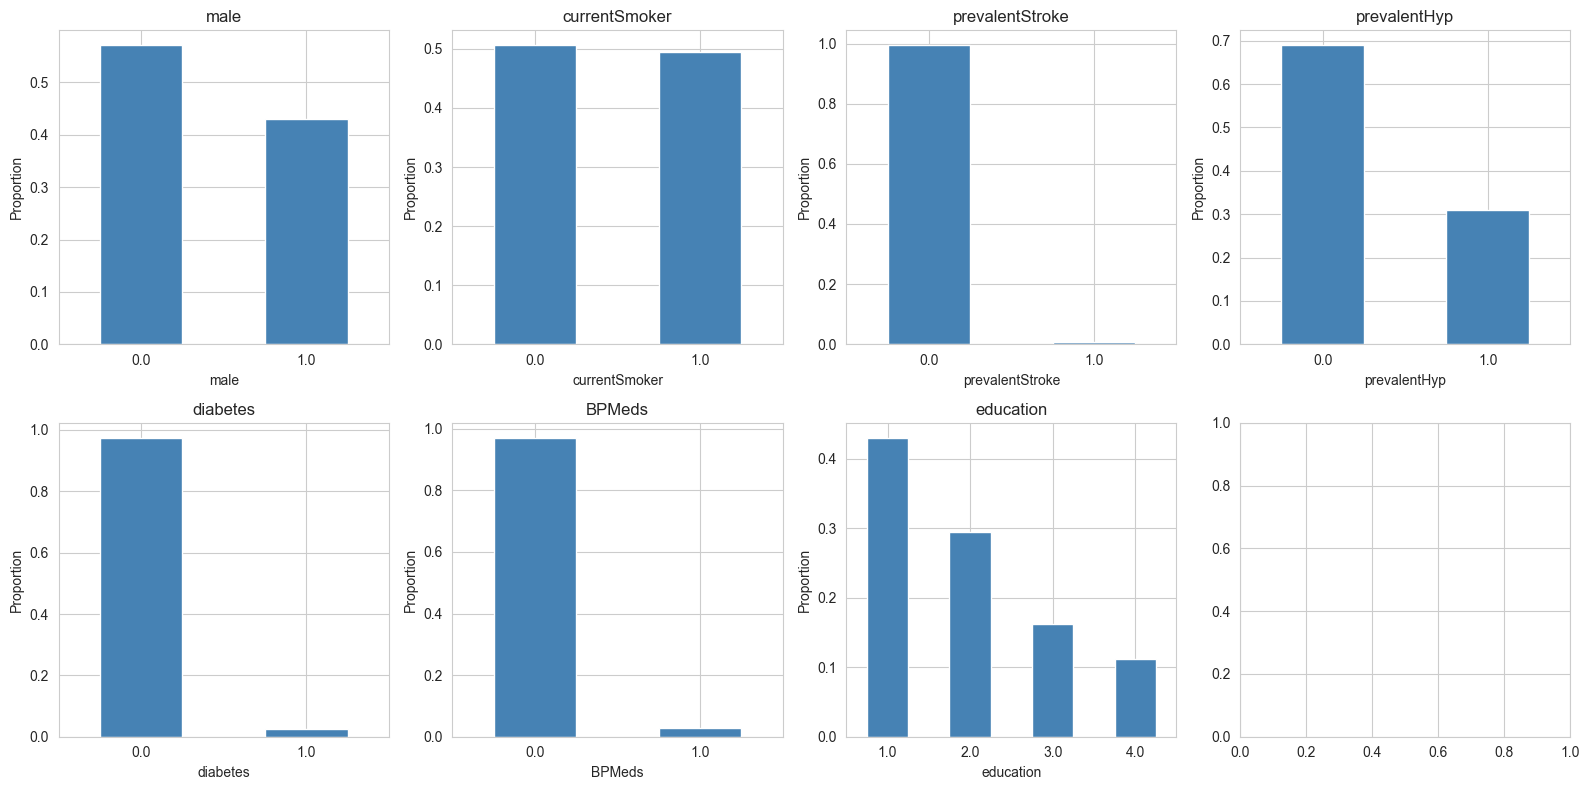

In [15]:
# categorical features distribution

cat_cols = ['male', 'currentSmoker', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'BPMeds', 'education']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < len(cat_cols):
        df[col].value_counts(normalize=True).plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('Proportion')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150)
plt.show()

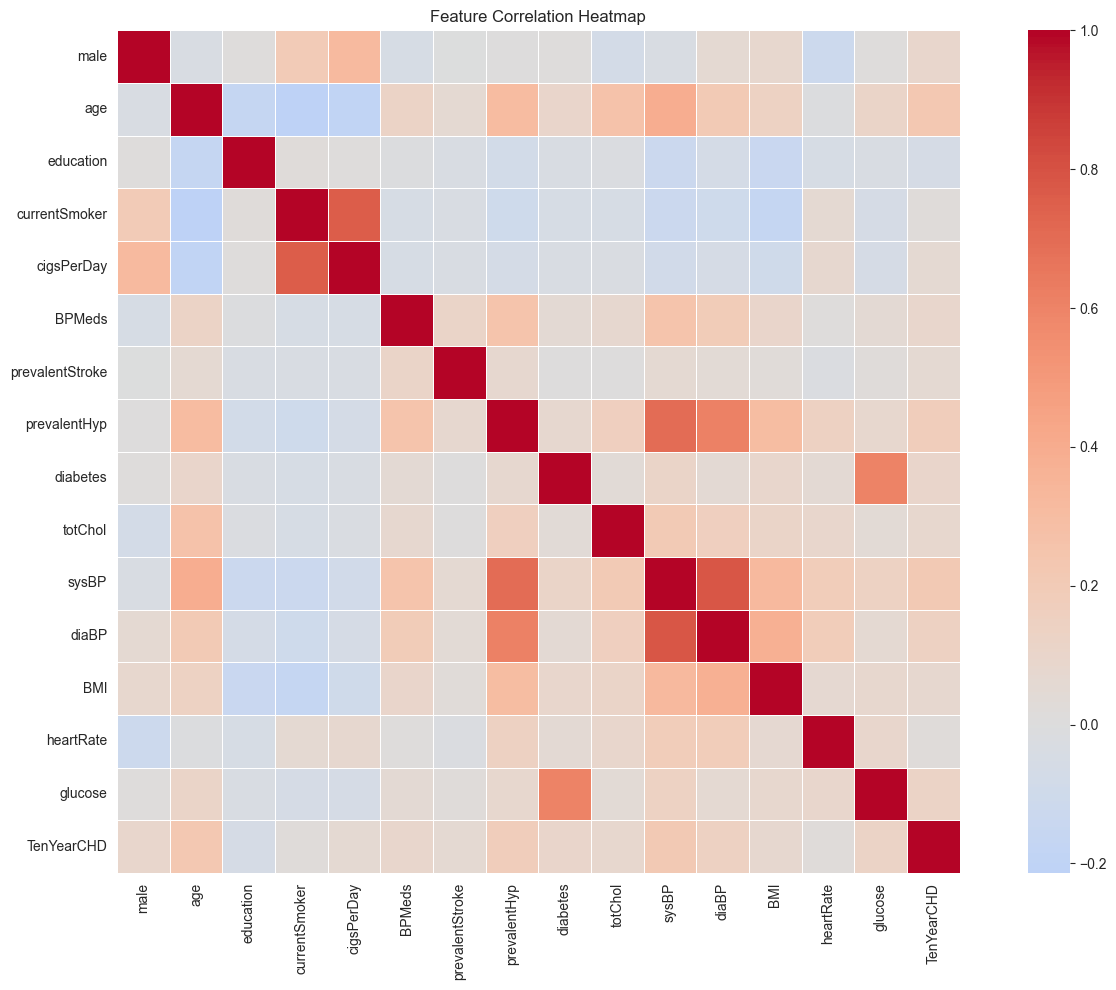

TOP CORRELATIONS WITH TenYearCHD
age                0.225408
sysBP              0.216374
prevalentHyp       0.177458
diaBP              0.145112
glucose            0.121319
diabetes           0.097344
male               0.088374
BPMeds             0.086448
totChol            0.081749
BMI                0.074326
prevalentStroke    0.061823
cigsPerDay         0.058729
heartRate          0.022851
currentSmoker      0.019448
education         -0.053002
Name: TenYearCHD, dtype: float64


In [16]:
# correlation heatmap

plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Show top correlations with target

print("TOP CORRELATIONS WITH TenYearCHD")
target_corr = corr_matrix['TenYearCHD'].drop('TenYearCHD').sort_values(ascending=False)
print(target_corr)


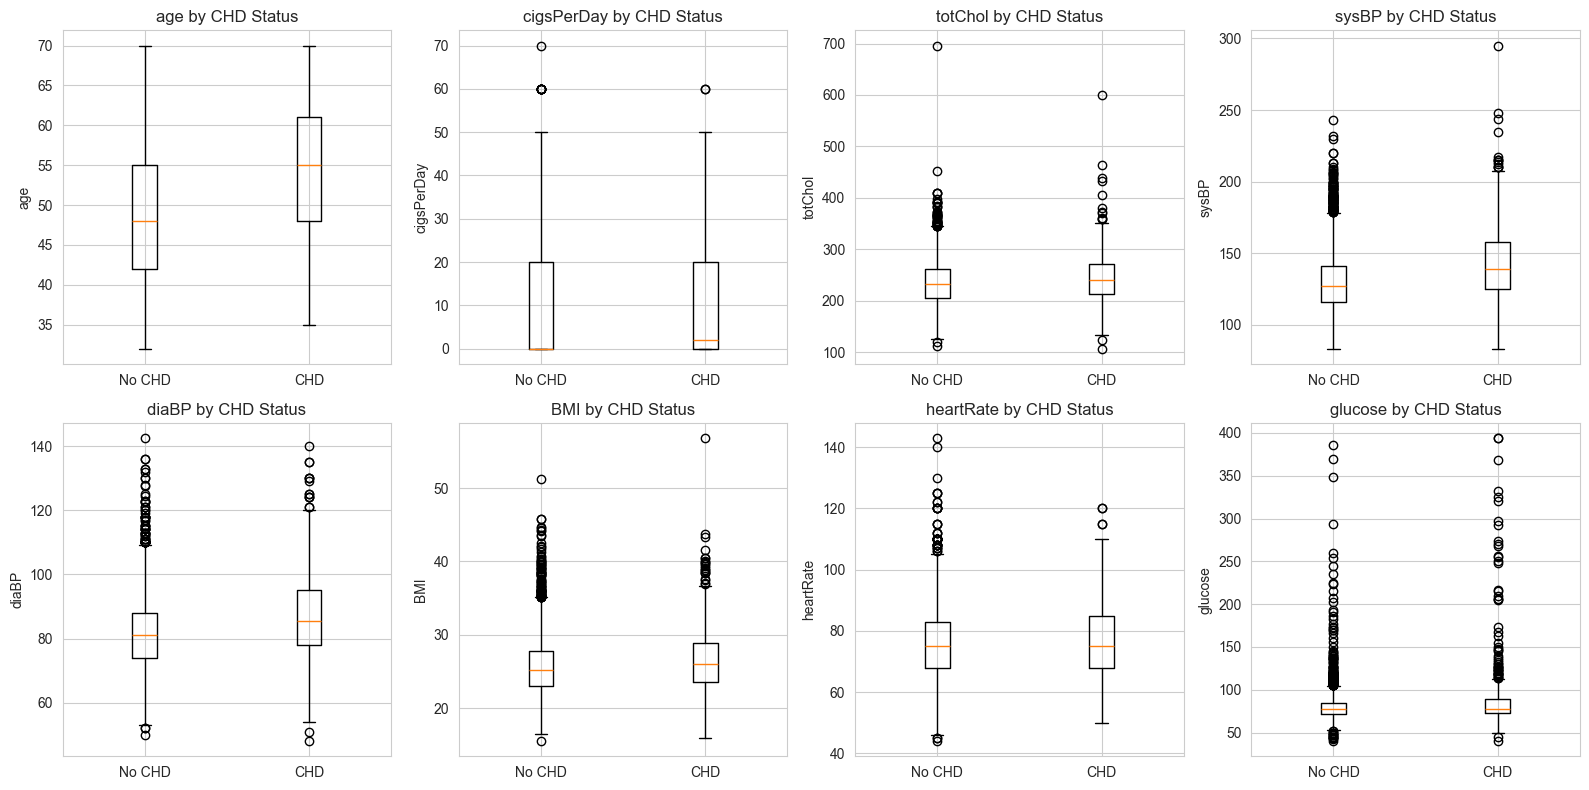

In [17]:
#comparing features by target

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot([df[df['TenYearCHD'] == 0][col].dropna(), 
                     df[df['TenYearCHD'] == 1][col].dropna()], 
                    tick_labels=['No CHD', 'CHD'])
    axes[i].set_title(f'{col} by CHD Status')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('numeric_by_target.png', dpi=150)
plt.show()


/var/folders/5k/_gksryk518l5_c3d_m8z20c00000gn/T/ipykernel_5949/2784110475.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chd_by_age = df.groupby(age_bins)['TenYearCHD'].mean()


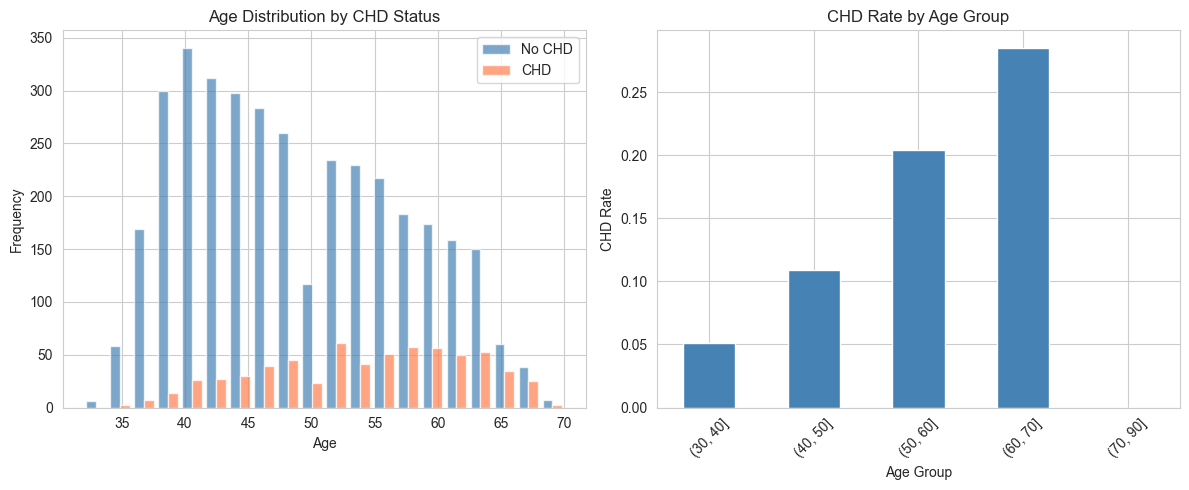

In [18]:
#age analysis by target

plt.figure(figsize=(12, 5))

# Age distribution by CHD status
plt.subplot(1, 2, 1)
plt.hist([df[df['TenYearCHD'] == 0]['age'], df[df['TenYearCHD'] == 1]['age']], 
         bins=20, label=['No CHD', 'CHD'], alpha=0.7, color=['steelblue', 'coral'])
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by CHD Status')
plt.legend()

# CHD rate by age group
plt.subplot(1, 2, 2)
age_bins = pd.cut(df['age'], bins=[30,40,50,60,70,90])
chd_by_age = df.groupby(age_bins)['TenYearCHD'].mean()
chd_by_age.plot(kind='bar', color='steelblue')
plt.xlabel('Age Group')
plt.ylabel('CHD Rate')
plt.title('CHD Rate by Age Group')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('age_analysis.png', dpi=150)
plt.show()

In [19]:

print("EDA SUMMARY")
print(f"""
Key Observations:
- Dataset size: {df.shape[0]} patients, {df.shape[1]} features
- CHD events: {df['TenYearCHD'].sum()} ({df['TenYearCHD'].mean()*100:.2f}%)
- Missing data exists in glucose, totChol, BMI, heartRate, and cigsPerDay
- Strongest positive correlations with TenYearCHD:
  {target_corr.head(3).to_dict()}
- Strongest negative correlations with TenYearCHD:
  {target_corr.tail(3).to_dict()}

""")

EDA SUMMARY

Key Observations:
- Dataset size: 4240 patients, 16 features
- CHD events: 644 (15.19%)
- Missing data exists in glucose, totChol, BMI, heartRate, and cigsPerDay
- Strongest positive correlations with TenYearCHD:
  {'age': 0.22540774458750037, 'sysBP': 0.216373828929235, 'prevalentHyp': 0.17745756074899732}
- Strongest negative correlations with TenYearCHD:
  {'heartRate': 0.022850755264927403, 'currentSmoker': 0.019448498478190412, 'education': -0.053001798536984085}




In [20]:
 #PREPARE FEATURES AND TARGET

print("PREPARING DATA FOR MODELING")

# Define features (X) and target (y)
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Split into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set CHD rate: {y_train.mean() * 100:.2f}%")
print(f"Test set CHD rate: {y_test.mean() * 100:.2f}%")


PREPARING DATA FOR MODELING
Training set size: 3392 samples
Test set size: 848 samples

Training set CHD rate: 15.18%
Test set CHD rate: 15.21%


In [22]:
# 6. FEATURE SCALING
print("FEATURE SCALING (Standardization)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features have been standardized (mean=0, std=1)")


FEATURE SCALING (Standardization)
✓ Features have been standardized (mean=0, std=1)


In [23]:
print("APPLYING SMOTE (Synthetic Minority Over-sampling)")
print("=" * 50)

# Check original class distribution
print(f"Before SMOTE - Class 0: {sum(y_train == 0)}, Class 1: {sum(y_train == 1)}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Class 0: {sum(y_train_resampled == 0)}, Class 1: {sum(y_train_resampled == 1)}")
print(f"✓ Classes are now balanced")


APPLYING SMOTE (Synthetic Minority Over-sampling)
Before SMOTE - Class 0: 2877, Class 1: 515
After SMOTE - Class 0: 2877, Class 1: 2877
✓ Classes are now balanced


In [24]:
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 50)

# Model 1: Logistic Regression
print("\n[1] Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest
print("[2] Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]


TRAINING MACHINE LEARNING MODELS

[1] Training Logistic Regression...
[2] Training Random Forest...


In [25]:
print("MODEL EVALUATION RESULTS")

# Logistic Regression Results
print("\n" + "-" * 30)
print("LOGISTIC REGRESSION")
print("-" * 30)
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['No CHD', 'CHD']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

MODEL EVALUATION RESULTS

------------------------------
LOGISTIC REGRESSION
------------------------------
ROC-AUC Score: 0.6962

Classification Report:
              precision    recall  f1-score   support

      No CHD       0.90      0.68      0.78       719
         CHD       0.25      0.60      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.67      0.71       848


Confusion Matrix:
[[488 231]
 [ 52  77]]


In [26]:
# Random Forest Results
print("\n" + "-" * 30)
print("RANDOM FOREST")
print("-" * 30)
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['No CHD', 'CHD']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))



------------------------------
RANDOM FOREST
------------------------------
ROC-AUC Score: 0.6599

Classification Report:
              precision    recall  f1-score   support

      No CHD       0.88      0.82      0.85       719
         CHD       0.28      0.39      0.33       129

    accuracy                           0.76       848
   macro avg       0.58      0.61      0.59       848
weighted avg       0.79      0.76      0.77       848


Confusion Matrix:
[[592 127]
 [ 79  50]]


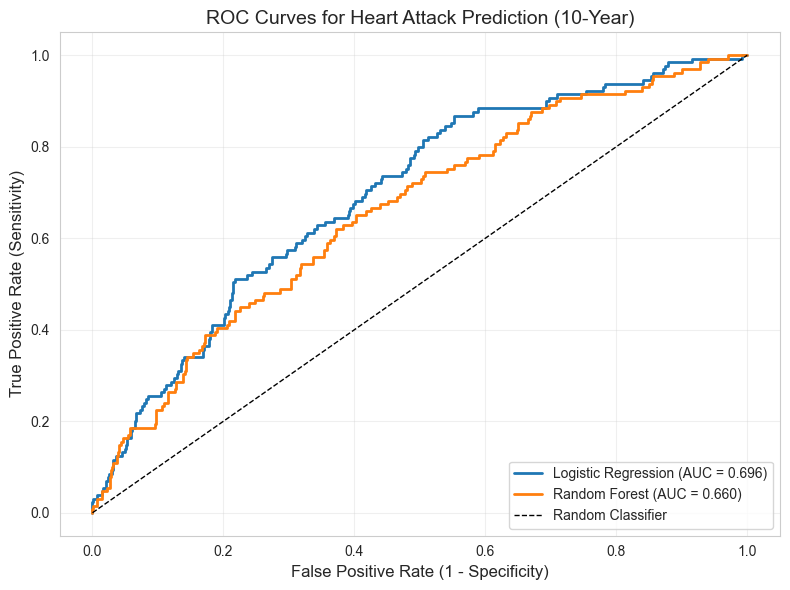

In [27]:
# ============================================
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
auc_lr = roc_auc_score(y_test, lr_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
auc_rf = roc_auc_score(y_test, rf_proba)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves for Heart Attack Prediction (10-Year)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [31]:
"""
IMPROVED MODEL - Part 3: Advanced Algorithms
"""

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier

# Prepare data with engineered features
X_eng = df_engineered.drop('TenYearCHD', axis=1)
y_eng = df_engineered['TenYearCHD']

# Split and scale
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

# Scale only numeric columns (not dummies)
scaler_eng = StandardScaler()
numeric_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
                'cholesterol_age_risk', 'bp_product', 'smoking_intensity', 'metabolic_risk',
                'age_bmi_interaction']
X_train_eng[numeric_cols] = scaler_eng.fit_transform(X_train_eng[numeric_cols])
X_test_eng[numeric_cols] = scaler_eng.transform(X_test_eng[numeric_cols])

# Apply SMOTE
X_train_res_eng, y_train_res_eng = smote.fit_resample(X_train_eng, y_train_eng)

# ============================================
# XGBOOST (Often performs best on tabular data)
# ============================================
print("=" * 60)
print("XGBOOST CLASSIFIER")
print("=" * 60)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_res_eng, y_train_res_eng)
xgb_proba = xgb_model.predict_proba(X_test_eng)[:, 1]
xgb_auc = roc_auc_score(y_test_eng, xgb_proba)
print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")

# ============================================
# LIGHTGBM (Fast and often better than XGBoost)
# ============================================
print("\n" + "=" * 60)
print("LIGHTGBM CLASSIFIER")
print("=" * 60)

lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train_res_eng, y_train_res_eng)
lgb_proba = lgb_model.predict_proba(X_test_eng)[:, 1]
lgb_auc = roc_auc_score(y_test_eng, lgb_proba)
print(f"LightGBM ROC-AUC: {lgb_auc:.4f}")

# ============================================
# VOTING CLASSIFIER (Combine multiple models)
# ============================================
print("\n" + "=" * 60)
print("VOTING CLASSIFIER (Ensemble)")
print("=" * 60)

voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft'  # Use predicted probabilities
)

voting_model.fit(X_train_res_eng, y_train_res_eng)
voting_proba = voting_model.predict_proba(X_test_eng)[:, 1]
voting_auc = roc_auc_score(y_test_eng, voting_proba)
print(f"Voting Classifier ROC-AUC: {voting_auc:.4f}")

NameError: name 'df_engineered' is not defined

In [ ]:
|